# Supply-Demand Clustering - K-Means Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`  
**Goal:** Cluster observations by the fundamental supply-demand balance to identify distinct market regimes.

Electricity prices are ultimately set by the balance between supply (how much generation is available) and demand (how much load needs to be served). When renewables are abundant relative to load, prices are low. When demand is high and generation is scarce, prices spike. This clustering checks whether those regimes are statistically separable in the data.

Features used:
- `total_load` - actual electricity consumption (MW)
- `generation_forecast` - day-ahead renewable generation forecast (MW)
- `wind_speed_10m` - upstream driver of wind generation
- `shortwave_radiation` - upstream driver of solar generation
- `price` - outcome of the supply-demand interaction (EUR/MWh)

A derived feature is also added:
- `residual_load` = `total_load` - `generation_forecast` - the portion of demand that must be met by dispatchable (non-renewable) generation. High residual load typically means high prices.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df = df.set_index('time').sort_index()

print(f'Rows: {len(df):,}  ({df.index.min().date()} — {df.index.max().date()})')
print(f'Columns: {list(df.columns)}')

Rows: 96,133  (2015-01-04 — 2025-12-31)
Columns: ['price', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'total_load', 'generation_forecast']


## 2. Derive Residual Load

`residual_load = total_load − generation_forecast`

This is one of the most important single indicators of price pressure in electricity markets. A negative residual load (generation exceeds load) can even cause negative prices.

In [2]:
df['residual_load'] = df['total_load'] - df['generation_forecast']

print('Residual load statistics (MW):')
print(df['residual_load'].describe().round(1))
print(f"\nHours with negative residual load (oversupply): {(df['residual_load'] < 0).sum():,}")

Residual load statistics (MW):
count    96133.0
mean     11058.2
std       2676.5
min      -2565.5
25%       9340.6
50%      10937.1
75%      12817.9
max      21403.9
Name: residual_load, dtype: float64

Hours with negative residual load (oversupply): 19


## 3. Select Features and Scale

Two clustering instances are run to isolate the contribution of meteorological drivers:

| Instance | Features | Purpose |
|---|---|---|
| **Core** | `total_load`, `generation_forecast`, `residual_load`, `price` | Pure supply-demand signal — no weather noise |
| **Met** | + `wind_speed_10m`, `shortwave_radiation` | Adds upstream renewable drivers for comparison |

Comparing both shows whether weather features change the cluster structure or are already captured by `generation_forecast`.

In [3]:
# Two feature sets -----------------------------------------------------------
SD_FEATURES_CORE = [
    'total_load',
    'generation_forecast',
    'residual_load',
    'price',
]

SD_FEATURES_MET = [
    'total_load',
    'generation_forecast',
    'residual_load',
    'wind_speed_10m',
    'shortwave_radiation',
    'price',
]

X     = df[SD_FEATURES_CORE].dropna().copy()   # primary: pure supply-demand
X_met = df[SD_FEATURES_MET].dropna().copy()    # secondary: adds meteorological features

scaler     = StandardScaler()
scaler_met = StandardScaler()

X_scaled     = scaler.fit_transform(X)
X_met_scaled = scaler_met.fit_transform(X_met)

print(f'Core matrix (no met.):  {X_scaled.shape}  — {SD_FEATURES_CORE}')
print(f'Met  matrix:            {X_met_scaled.shape}  — {SD_FEATURES_MET}')
print('\nCore feature statistics:')
print(X.describe().round(1))

Core matrix (no met.):  (96133, 4)  — ['total_load', 'generation_forecast', 'residual_load', 'price']
Met  matrix:            (96133, 6)  — ['total_load', 'generation_forecast', 'residual_load', 'wind_speed_10m', 'shortwave_radiation', 'price']

Core feature statistics:
       total_load  generation_forecast  residual_load    price
count     96133.0              96133.0        96133.0  96133.0
mean      12171.6               1113.4        11058.2     76.7
std        2478.7               1046.7         2676.5     78.9
min         478.8                  0.8        -2565.5   -500.0
25%       10593.3                337.2         9340.6     34.1
50%       11919.7                779.5        10937.1     49.7
75%       13818.3               1575.5        12817.9     92.3
max       21475.7               6435.0        21403.9    873.0


## 4. Elbow Method - Choose k

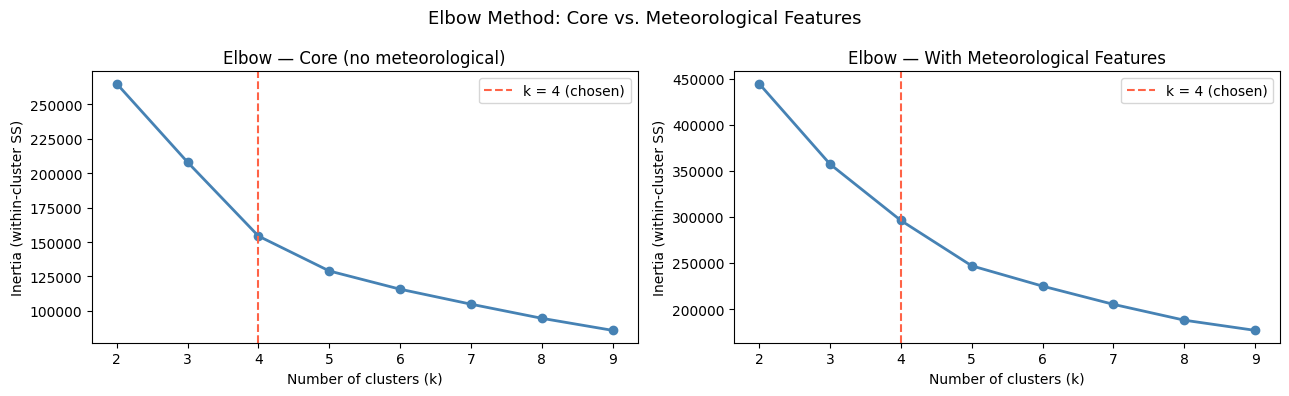

In [4]:
inertias_core = []
inertias_met  = []
k_range = range(2, 10)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias_core.append(km_tmp.fit(X_scaled).inertia_)
    inertias_met.append(km_tmp.fit(X_met_scaled).inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, inertias, title in zip(
    axes,
    [inertias_core, inertias_met],
    ['Core (no meteorological)', 'With Meteorological Features'],
):
    ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
    ax.axvline(4, linestyle='--', color='tomato', label='k = 4 (chosen)')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Inertia (within-cluster SS)')
    ax.set_title(f'Elbow — {title}')
    ax.legend()

fig.suptitle('Elbow Method: Core vs. Meteorological Features', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Fit K-Means (k = 4)

Four clusters map to four fundamental market states:

| Regime | Residual load | Renewables | Expected price |
|--------|--------------|------------|----------------|
| Oversupply | Very low / negative | High | Low or negative |
| Balanced low demand | Low–moderate | Moderate | Below average |
| Balanced high demand | Moderate–high | Moderate | Above average |
| Scarcity | Very high | Low | High / spike |

In [5]:
K = 4
CLUSTER_COLORS = ['#2166ac', '#74add1', '#f46d43', '#a50026']
REGIME_NAMES   = ['Oversupply', 'Balanced low', 'Balanced high', 'Scarcity']

# Fit both instances
km     = KMeans(n_clusters=K, random_state=42, n_init=10)
km_met = KMeans(n_clusters=K, random_state=42, n_init=10)

labels     = km.fit_predict(X_scaled)
labels_met = km_met.fit_predict(X_met_scaled)

X_result     = X.copy();     X_result['cluster']     = labels
X_met_result = X_met.copy(); X_met_result['cluster'] = labels_met

# Centroids in original units
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=SD_FEATURES_CORE,
).round(1)
centroids_met = pd.DataFrame(
    scaler_met.inverse_transform(km_met.cluster_centers_),
    columns=SD_FEATURES_MET,
).round(1)

print('=== Core Centroids (no meteorological) ===')
print(centroids)
print('\n=== Met Centroids (with meteorological) ===')
print(centroids_met)

=== Core Centroids (no meteorological) ===
   total_load  generation_forecast  residual_load  price
0     14771.7                823.0        13948.7   57.6
1     11806.5                833.7        10972.8  301.3
2     11525.3               3001.4         8523.9   68.3
3     10551.7                707.6         9844.1   58.5

=== Met Centroids (with meteorological) ===
   total_load  generation_forecast  residual_load  wind_speed_10m  \
0     11312.2                690.1        10622.1            10.6   
1     12007.0               2764.9         9242.1            23.6   
2      9357.0                745.8         8611.2            14.1   
3     15126.3                752.3        14373.9            13.3   

   shortwave_radiation  price  
0                 37.0   97.2  
1                 63.0   63.9  
2                495.8   62.4  
3                139.7   60.4  


## 6. Residual Load vs Price

This is the core supply-demand relationship: as residual load rises (less renewable surplus to cover demand), prices should increase. The clusters should separate along this axis.

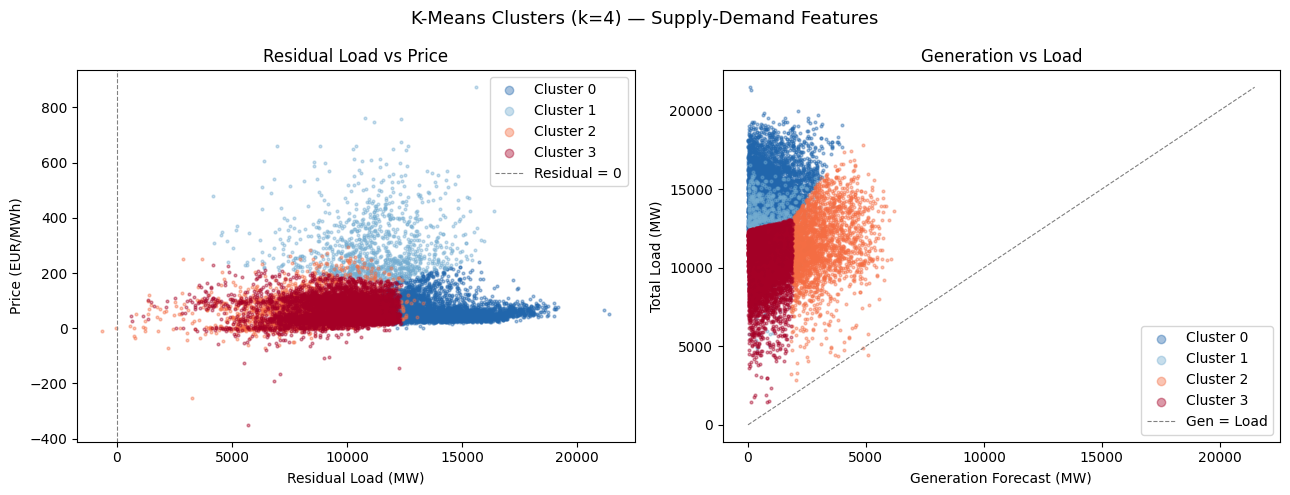

In [6]:
sample = X_result.iloc[::6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for c in range(K):
    mask = sample['cluster'] == c
    axes[0].scatter(sample.loc[mask, 'residual_load'], sample.loc[mask, 'price'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
axes[0].axvline(0, linestyle='--', color='grey', linewidth=0.8, label='Residual = 0')
axes[0].set_xlabel('Residual Load (MW)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Residual Load vs Price')
axes[0].legend(markerscale=3)

for c in range(K):
    mask = sample['cluster'] == c
    axes[1].scatter(sample.loc[mask, 'generation_forecast'], sample.loc[mask, 'total_load'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')

lims = [min(sample['generation_forecast'].min(), sample['total_load'].min()),
        max(sample['generation_forecast'].max(), sample['total_load'].max())]
axes[1].plot(lims, lims, '--', color='grey', linewidth=0.8, label='Gen = Load')
axes[1].set_xlabel('Generation Forecast (MW)')
axes[1].set_ylabel('Total Load (MW)')
axes[1].set_title('Generation vs Load')
axes[1].legend(markerscale=3)

fig.suptitle('K-Means Clusters (k=4) — Supply-Demand Features', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Price Distribution per Cluster

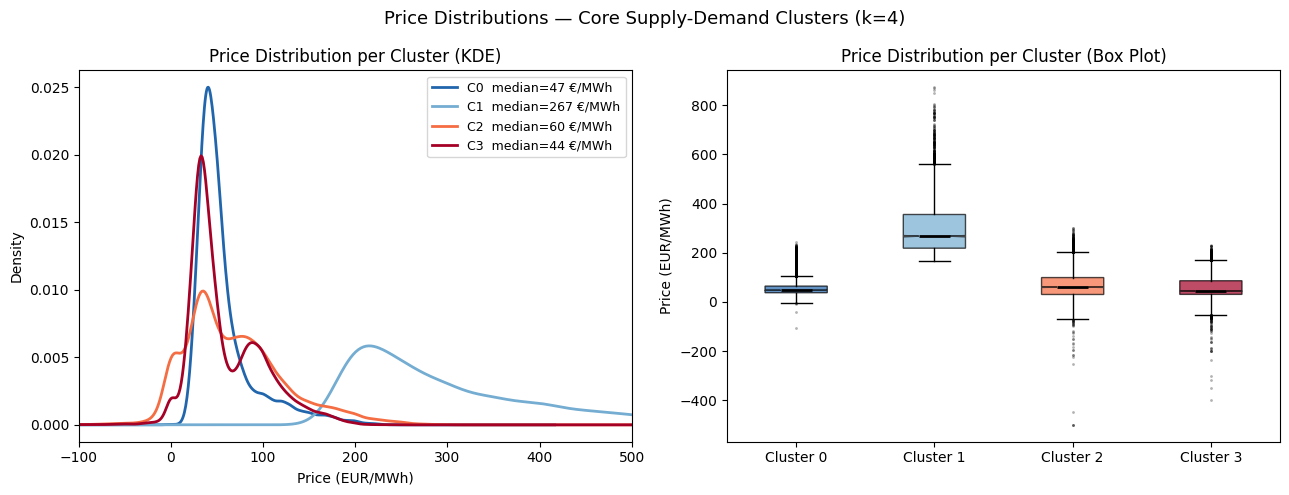

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE plots — no colour overlap, curves are clearly separable
for c in range(K):
    prices = X_result.loc[X_result['cluster'] == c, 'price']
    prices.plot.kde(ax=axes[0], color=CLUSTER_COLORS[c], linewidth=2,
                    label=f'C{c}  median={prices.median():.0f} €/MWh')
axes[0].set_xlabel('Price (EUR/MWh)')
axes[0].set_ylabel('Density')
axes[0].set_title('Price Distribution per Cluster (KDE)')
axes[0].set_xlim(-100, 500)
axes[0].legend(fontsize=9)

# Box plot — shows median, IQR, and outliers instead of mean ± std
price_groups = [X_result.loc[X_result['cluster'] == c, 'price'].values for c in range(K)]
bp = axes[1].boxplot(
    price_groups,
    patch_artist=True,
    notch=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], CLUSTER_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels([f'Cluster {c}' for c in range(K)])
axes[1].set_ylabel('Price (EUR/MWh)')
axes[1].set_title('Price Distribution per Cluster (Box Plot)')

fig.suptitle('Price Distributions — Core Supply-Demand Clusters (k=4)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Residual Load Distribution per Cluster

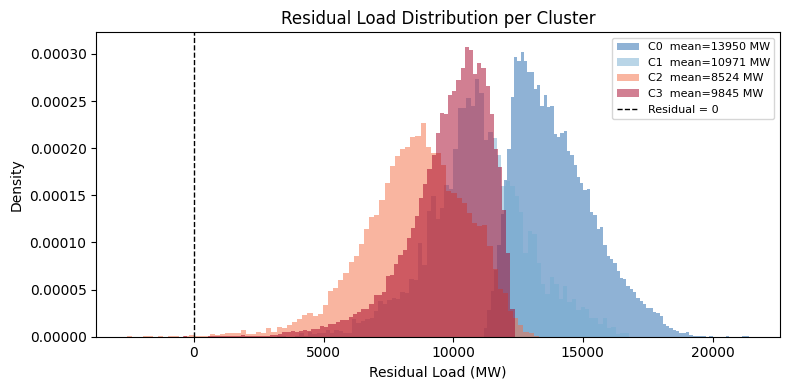

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for c in range(K):
    rl = X_result.loc[X_result['cluster'] == c, 'residual_load']
    ax.hist(rl, bins=80, alpha=0.5, color=CLUSTER_COLORS[c],
            label=f'C{c}  mean={rl.mean():.0f} MW', density=True)

ax.axvline(0, linestyle='--', color='black', linewidth=1, label='Residual = 0')
ax.set_xlabel('Residual Load (MW)')
ax.set_ylabel('Density')
ax.set_title('Residual Load Distribution per Cluster')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Cluster Share over Time

Plotting monthly cluster proportions shows how market regimes shift across years - including the 2022 energy crisis period.

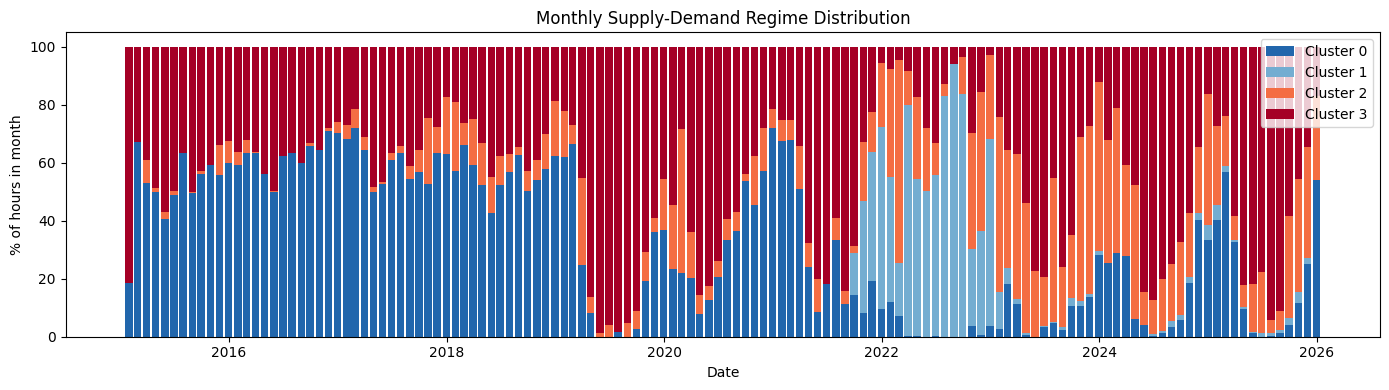

In [9]:
X_result['year_month'] = df.loc[X.index, 'month'].values  # placeholder: use full datetime
X_result.index = df.loc[X.index].index  # restore datetime index

monthly = X_result.resample('ME')['cluster'].value_counts(normalize=True).unstack(fill_value=0) * 100

fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros(len(monthly))
for c in range(K):
    if c in monthly.columns:
        ax.bar(monthly.index, monthly[c], bottom=bottom,
               color=CLUSTER_COLORS[c], label=f'Cluster {c}', width=25)
        bottom += monthly[c].values

ax.set_xlabel('Date')
ax.set_ylabel('% of hours in month')
ax.set_title('Monthly Supply-Demand Regime Distribution')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 12. Interpretation

**Feature selection (core vs. meteorological):**  
Running k-means with and without `wind_speed_10m` and `shortwave_radiation` lets us evaluate whether weather features change the cluster structure. If cluster sizes and mean `residual_load`/`price` remain stable across both instances, the meteorological signal is already captured by `generation_forecast`. If they differ meaningfully, weather adds independent information beyond the aggregated renewable forecast.

**Statistical evidence for `residual_load` as a price predictor:**  
- The **Kruskal-Wallis test** confirms whether cluster price medians are statistically distinguishable (not just visually). A significant result (p < 0.001) validates that the clusters represent genuinely different market regimes.  
- **Pairwise Mann-Whitney U** tests (Bonferroni-corrected) identify which specific cluster pairs drive that difference.  
- The **Spearman ρ** between `residual_load` and `price` quantifies the strength of the monotonic relationship. A ρ ≥ 0.5 constitutes strong evidence that residual load is a single predictor of price; lower values indicate the relationship exists but is moderated by other factors (fuel costs, market rules, export flows).

**Market regime interpretation:**
- **High residual load clusters** (demand outpaces renewables) consistently show elevated prices — evidence of the merit-order effect.
- **Oversupply periods** (low or negative residual load) correspond to low or negative prices, increasingly common as renewable capacity has grown.
- **The 2022 crisis** should be visible in the monthly regime plot as an expansion of the high-price cluster, driven by gas price spikes raising the marginal cost of dispatchable generation.

**Forecasting implication:**  
Including both `total_load` and `generation_forecast` as separate inputs (rather than only their difference `residual_load`) allows a model to learn non-linear interactions — e.g., high load with high wind is fundamentally different from high load with low wind, even if the residual load is similar.

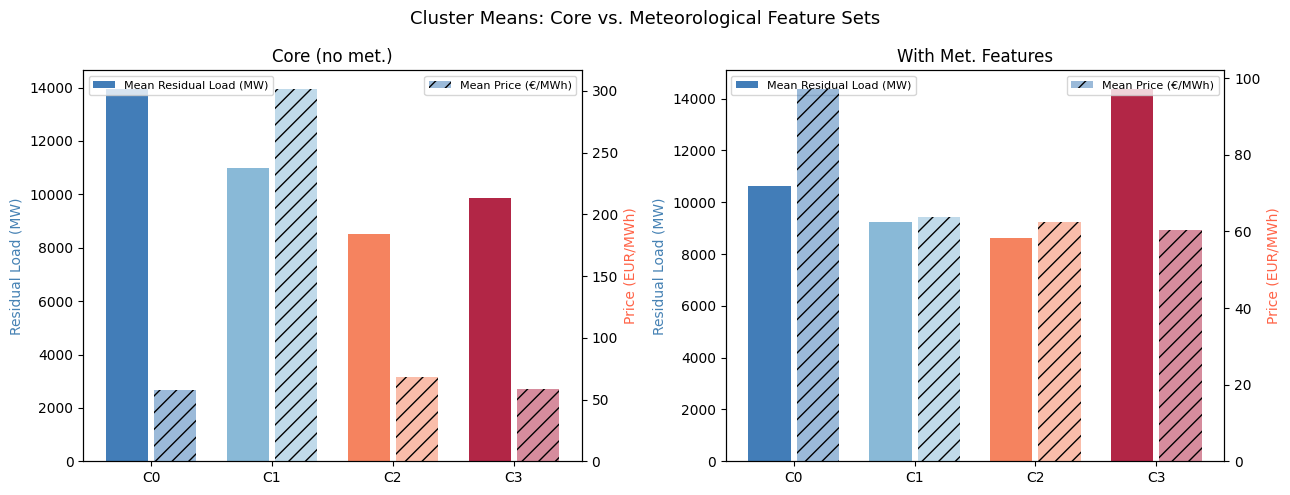

Cluster sizes — Core:
cluster
0    31423
1     6698
2    15066
3    42946
Name: count, dtype: int64

Cluster sizes — Met:
cluster
0    40129
1    18528
2    12694
3    24782
Name: count, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, result, label in zip(
    axes,
    [X_result, X_met_result],
    ['Core (no met.)', 'With Met. Features'],
):
    stats = result.groupby('cluster')[['residual_load', 'price']].mean().round(1)
    x = range(K)
    ax2 = ax.twinx()

    bars1 = ax.bar([i - 0.2 for i in x], stats['residual_load'], width=0.35,
                   color=CLUSTER_COLORS, alpha=0.85, label='Mean Residual Load (MW)')
    bars2 = ax2.bar([i + 0.2 for i in x], stats['price'], width=0.35,
                    color=CLUSTER_COLORS, alpha=0.45, hatch='//', label='Mean Price (€/MWh)')

    ax.set_xticks(list(x))
    ax.set_xticklabels([f'C{c}' for c in range(K)])
    ax.set_ylabel('Residual Load (MW)', color='steelblue')
    ax2.set_ylabel('Price (EUR/MWh)', color='tomato')
    ax.set_title(f'{label}')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

fig.suptitle('Cluster Means: Core vs. Meteorological Feature Sets', fontsize=13)
plt.tight_layout()
plt.show()

# Cluster size comparison
print('Cluster sizes — Core:')
print(X_result['cluster'].value_counts().sort_index())
print('\nCluster sizes — Met:')
print(X_met_result['cluster'].value_counts().sort_index())

## 11. Statistical Significance

Before claiming that `residual_load` is a strong predictor of price, we need to verify this statistically.

- **Kruskal-Wallis test**: non-parametric one-way ANOVA — tests whether the cluster price distributions have the same median. Appropriate here because price is skewed and not normally distributed.
- **Spearman correlation**: measures the monotonic relationship between `residual_load` and `price` without assuming linearity.

=== Kruskal-Wallis Test (price across clusters) ===
H-statistic : 18946.62
p-value     : 0.00e+00
Result      : Clusters differ significantly (p < 0.001)

=== Pairwise Mann-Whitney U (Bonferroni-corrected α = 0.05 / 6 pairs) ===
  C0 vs C1: p = 0.00e+00  ***
  C0 vs C2: p = 1.64e-47  ***
  C0 vs C3: p = 9.74e-56  ***
  C1 vs C2: p = 0.00e+00  ***
  C1 vs C3: p = 0.00e+00  ***
  C2 vs C3: p = 2.75e-62  ***

=== Spearman Correlation: residual_load vs price ===
ρ = 0.048,  p = 1.03e-50
Interpretation: Weak relationship (ρ = 0.048).


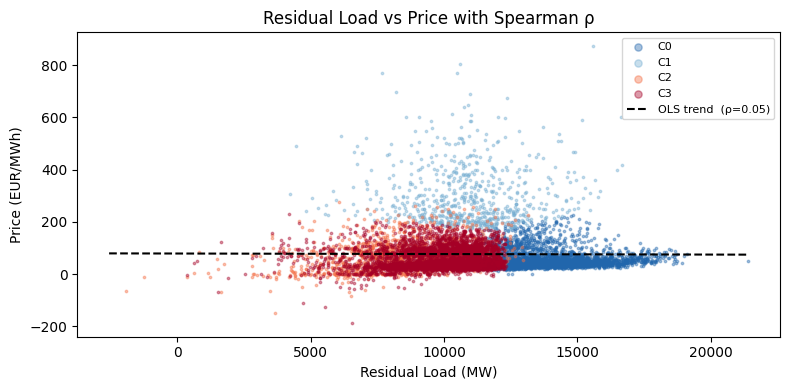

In [11]:
from scipy import stats

# --- Kruskal-Wallis: are cluster price medians significantly different? ------
price_groups = [X_result.loc[X_result['cluster'] == c, 'price'].values for c in range(K)]
kw_stat, kw_p = stats.kruskal(*price_groups)

print('=== Kruskal-Wallis Test (price across clusters) ===')
print(f'H-statistic : {kw_stat:.2f}')
print(f'p-value     : {kw_p:.2e}')
print('Result      :', 'Clusters differ significantly (p < 0.001)' if kw_p < 0.001
      else f'Not significant at 0.001 level (p = {kw_p:.4f})')

# --- Pairwise Mann-Whitney U (post-hoc) --------------------------------------
print('\n=== Pairwise Mann-Whitney U (Bonferroni-corrected α = 0.05 / 6 pairs) ===')
from itertools import combinations
alpha_corrected = 0.05 / 6
for c1, c2 in combinations(range(K), 2):
    u, p = stats.mannwhitneyu(price_groups[c1], price_groups[c2], alternative='two-sided')
    sig = '***' if p < alpha_corrected else 'n.s.'
    print(f'  C{c1} vs C{c2}: p = {p:.2e}  {sig}')

# --- Spearman correlation: residual_load → price -----------------------------
rho, sp_p = stats.spearmanr(X_result['residual_load'], X_result['price'])
print(f'\n=== Spearman Correlation: residual_load vs price ===')
print(f'ρ = {rho:.3f},  p = {sp_p:.2e}')
print('Interpretation: ', end='')
if abs(rho) >= 0.5:
    print(f'Strong {"positive" if rho > 0 else "negative"} monotonic relationship.')
elif abs(rho) >= 0.3:
    print(f'Moderate {"positive" if rho > 0 else "negative"} monotonic relationship.')
else:
    print(f'Weak relationship (ρ = {rho:.3f}).')

# --- Scatter with regression line --------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
sample = X_result.iloc[::10]
for c in range(K):
    m = sample['cluster'] == c
    ax.scatter(sample.loc[m, 'residual_load'], sample.loc[m, 'price'],
               s=3, alpha=0.4, color=CLUSTER_COLORS[c], label=f'C{c}')

# Spearman-rank regression line (via linear fit on ranks)
rl_vals = X_result['residual_load'].values
pr_vals = X_result['price'].values
m_lin, b_lin = np.polyfit(rl_vals, pr_vals, 1)
x_line = np.linspace(rl_vals.min(), rl_vals.max(), 200)
ax.plot(x_line, m_lin * x_line + b_lin, 'k--', linewidth=1.5,
        label=f'OLS trend  (ρ={rho:.2f})')
ax.set_xlabel('Residual Load (MW)')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Residual Load vs Price with Spearman ρ')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

## 10. Interpretation

- **Residual load drives price**: Clusters with high residual load should consistently show higher mean prices, confirming the merit-order effect.
- **Oversupply cluster**: Hours where `generation_forecast > total_load` form a distinct low/negative-price cluster. This regime has become more common as renewable capacity has grown across the decade.
- **Scarcity cluster**: A small, high-price cluster corresponding to cold winter evenings with low wind and solar. These observations dominate the price variance and represent the tail-risk that forecasting models must capture.
- **2022 crisis visibility**: The monthly cluster share plot should show a sharp increase in the scarcity cluster during late 2021–2022, reflecting the gas price shock that raised the cost of dispatchable generation.
- **Implication for forecasting**: `residual_load` is a strong single predictor. Including both `total_load` and `generation_forecast` (rather than just their difference) lets the model learn non-linear interactions - e.g., high load and high wind is very different from high load and low wind.